# Assignment 1 - Part 1 - MovieLens

## Introdcution:

This assignment is the first of a two-part project and focuses on analyzing the dataset provided by MovieLens, specifically the MovieLens 20M Dataset. The objective of this portion is to explore the data and address a series of problems outlined by the professor.

### Import Statements
The following statements import the modules required for this project, providing the necessary tools and functionality for data analysis.

In [1]:
#Import Statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as pn

### Reading Files

The following cell imports all available CSV files into the project. However, for the purposes of this analysis, only `movies.csv` and `ratings.csv` were utilized. Although additional CSV files were provided, they were not included, as they did not contribute meaningfully to addressing the research questions. The debug statement at the end displays the head of each dataset - the first five rows - to verify that the files were successfully loaded.

In [2]:
#Reading Files and checking the read works
moviesCsv = pd.read_csv('movies.csv')
ratingsCsv = pd.read_csv('ratings.csv')

#Simple Debug Statement
print('movies.csv preview:')
print(moviesCsv.head())
print("\nMovies shape:")
print(moviesCsv.shape)
print("\nMovies info:")
print(moviesCsv.info())
print()
print('\nratings.csv preview:')
print(ratingsCsv.head())
print("\nRatings shape:")
print(ratingsCsv.shape)
print("\nRatings info:")
print(ratingsCsv.info())

movies.csv preview:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Movies shape:
(27278, 3)

Movies info:
<class 'pandas.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  27278 non-null  int64
 1   title    27278 non-null  str  
 2   genres   27278 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB
None


ratings.csv pre

## Basic Info:

### How Many?
The first section asks us to determine the following attributes of the dataset:

* How many items are in the data set?
* How many users?
* How many ratings?
* What is the density of the data set?

For the number of items, I interpreted this as the number of movies in the dataset. To compute this, I counted the number of unique movie IDs in `movie.csv`. I chose to use `movie.csv` rather than `ratings.csv` because it provides a more complete representation of the catalog. In particular, some movies may exist in the dataset even if they were never rated, so relying on the ratings file alone could potentially undercount the total number of items.

For the number of users, I used `ratings.csv`, since there is no separate user metadata file. By extracting the unique user IDs from this dataset, I was able to capture all users who actively contributed ratings. To determine the total number of ratings, I simply calculated the length of the `ratings.csv` 

because I beleived that it would give a more complete picture, as there is a chance of a movie that is in the dataset, but just wassn't rated. For users, I chose to use `ratings.csv` because I believed that it would give me the most complete look of users in the dataset as there is no special csv for users. As for how many ratings, I just took the length of the dataset - note how the length is just a bit over 20 million, proving that it is right. dataset. This value is slightly over 20 million, which confirms that the dataset is large and sufficiently dense in terms of user interaction.

Finally, calculating the density of the dataset is a bit more involved. To begin, it is important to define what “density” means in this context. Density refers to how much of the possible user–item interaction space is actually filled with observed data. In other words, it measures the proportion of all potential user–item pairs for which we have an actual rating. To compute this, we take the total number of observed ratings and divide it by the product of the number of users and the number of items. This gives us a value between 0 and 1, where values closer to 1 indicate a very dense dataset, and values closer to 0 indicate a very sparse dataset.

In [3]:
# How many items (i.e. movies) are in the basic data set?
num_movies = moviesCsv['movieId'].nunique()
print("Items in the dataset:", num_movies)

#How many users in the data set?
num_users = ratingsCsv['userId'].nunique()
print("Users in the dataset:",num_users)

#How many ratings in the data set?
length_ratings = len(ratingsCsv)
print('Ratings in the dataset',length_ratings)
#You will notice that is just slightly over 20 Million

#Density of the Data Set
density = length_ratings / (num_movies * num_users)
print('Density:', density)

Items in the dataset: 27278
Users in the dataset: 138493
Ratings in the dataset 20000263
Density: 0.0052941392303578055


There is very little to say here in terms of analysis, as the variables are fairly straightforward. The only point worth noting is that the dataset is highly sparse, with a density of only about 0.5%.

### Distribution of User Rating Counts

The question asks: _“What is the distribution of user rating counts?”_. To answer this, I wrote the code shown below. Let’s go through what it does step by step.

The first line calculates how many ratings each user has made by using the groupby() and count() methods. More specifically, groupby('userId') groups the dataset so that all ratings from the same user are collected together. Then, selecting the rating column and applying count() counts the number of ratings within each user group. This results in a summary showing the total number of ratings contributed by each individual user.

The next line converts user_stats into a DataFrame using the to_frame() method and assigns a column name to it. 

The final line creates a distribution plot of the number of ratings per user, using Seaborn’s displot() function. Before plotting, the data is filtered to remove extreme values (outliers), specifically users who have more than 250 ratings. This is done to make the resulting graph more readable and to prevent a small number of very active users from skewing the visualization.

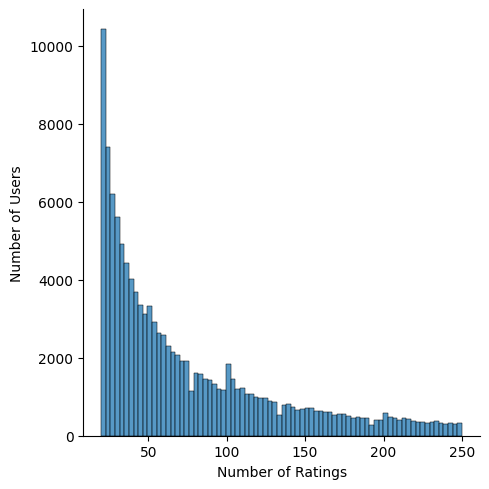

In [4]:
#Distribution of user rating counts
user_stats = ratingsCsv.groupby('userId')['rating'].count()
user_stats = user_stats.to_frame('n_ratings')
#Tried to filter some outliers here to the graph is somewhat readable
graph = sns.displot(user_stats[user_stats['n_ratings'] <= 250]['n_ratings'])
graph.set_axis_labels("Number of Ratings", "Number of Users")

As expected, most users contribute only a small number of ratings, with the majority falling under 50. As the number of ratings increases, the distribution drops off sharply, indicating that progressively fewer users are highly active in the dataset.

### Popularity Curve

This question asks, _“What is the item popularity curve (the distribution of ratings-per-item)?”_, and I was given the choice between a Lorenz Curve and a CDF plot. I chose to use the CDF plot for this analysis.

To begin, I grouped the dataset by movieId and counted the number of ratings each movie received. I then converted this result into a DataFrame and named the column n_rating, which clearly represents the number of ratings per movie.

Next, I extended this summary by joining additional statistics computed for each movie, including the mean rating and the sum of all ratings using agg(['mean', 'sum']). These columns were renamed to mean_rating and rating_sum to improve readability.

To better interpret item popularity in relative terms, I calculated a probability value for each movie by dividing its number of ratings by the total number of ratings in the dataset (length_ratings). This provides a normalized measure of how frequently each item is interacted with compared to the dataset as a whole.

Finally, I proceeded to the visualization step. The code generates a CDF (Cumulative Distribution Function) plot of item popularity using the item_stats DataFrame, where popularity is measured by the number of ratings each movie has received.

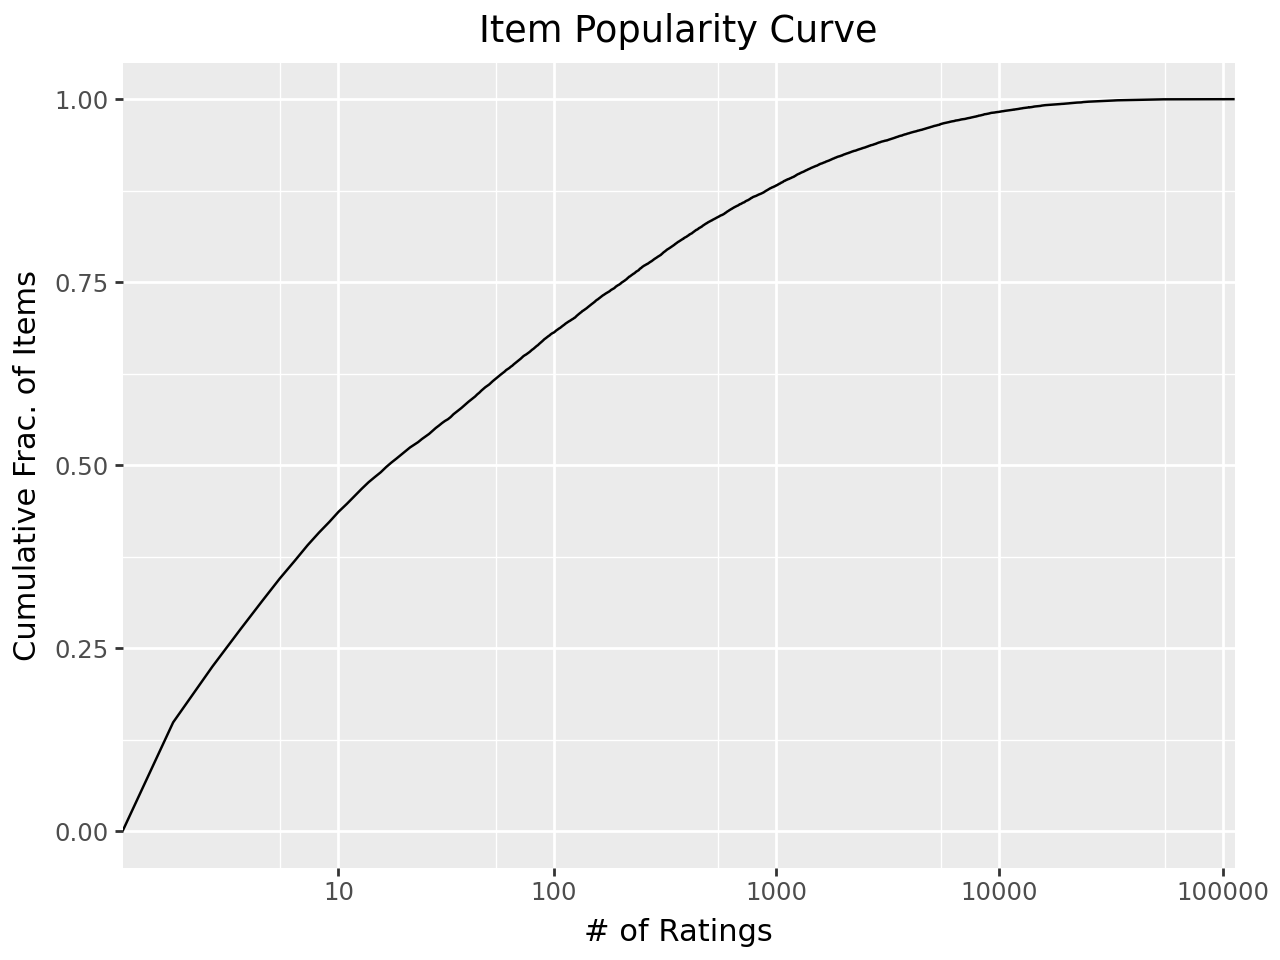

In [5]:
# What is the item popularity curve (the distribution of ratings-per-item)
item_stats = ratingsCsv.groupby('movieId')['rating'].count()
item_stats = item_stats.to_frame('n_rating')
item_stats = item_stats.join(ratingsCsv.groupby('movieId')['rating'].agg(['mean', 'sum']))
item_stats = item_stats.rename(columns={
    'mean': 'mean_rating',
    'sum': 'rating_sum'
})
item_stats['prob'] = item_stats['n_rating'] / length_ratings

# CDF Plot
(
    pn.ggplot(item_stats)
    + pn.aes(x='n_rating')
    + pn.geom_line(stat='ecdf')
    + pn.scale_x_symlog()
    + pn.labs(x='# of Ratings', y='Cumulative Frac. of Items')
    + pn.ggtitle("Item Popularity Curve")
)


A CDF plot shows the number of ratings per movie on the x-axis and the cumulative proportion of movies on the y-axis, where each point represents the fraction of movies that have at most that many ratings, meaning the curve increases as we move right and reveals that only a small number of movies receive very large numbers of ratings.

### Average Rating Distribution for Items

The question asks,_"What is the distribution of average ratings for items?"_. This code generates a histogram to visualize the distribution of average ratings across all items (movies). It uses plt.hist() to plot the mean_rating column from the item_stats DataFrame. The x-axis represents the average rating of movies, while the y-axis shows the number of movies.

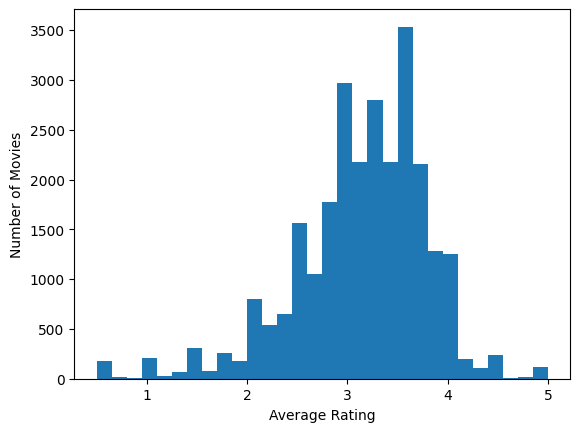

In [6]:
# What is the distribution of average ratings for items
plt.hist(item_stats['mean_rating'],bins=30)
plt.xlabel('Average Rating')
plt.ylabel('Number of Movies')
plt.show()

The distribution of average item ratings is centered around the mid-to-high range (approximately 3 to 4 stars), with relatively few movies receiving very low or very high average ratings. This suggests most movies are rated moderately positively, though averages may be influenced by the number of ratings per item.

## Non-Personalized Recommendation:

### Items With the Most Ratings

The question asks: _“What are the 10 most popular items (the items with the most ratings)? Show the item ID, item title, and the number of ratings.”_

To answer this, I first merged ratingsCsv and moviesCsv on movieId so that each rating entry includes both the item ID and its corresponding movie title. This ensures that popularity can be analyzed at the movie level while still retaining readable labels. I will be using merged_df more in the future, so make note of this. 

Next, I grouped the merged dataset by both movieId and title, and used .size() to count the number of ratings each movie received. This aggregation creates a new variable, number_of_ratings, which represents the total number of user ratings per movie. Finally, I used nlargest(10, 'number_of_ratings') to extract the 10 movies with the highest number of ratings, and reset the index to improve readability. The resulting output lists the item ID, movie title, and number of ratings for the most popular movies in the dataset.

In [7]:
#Merged csvs to have both movieID and movie title
merged_df = pd.merge(ratingsCsv,moviesCsv, on='movieId')

#Added Number of Ratings
num_ratings = (
    merged_df
    .groupby(['movieId', 'title'])
    .size()
    .reset_index(name='number_of_ratings')
)

# #Debug Statement - Check if number of ratings equal total amount of ratings
# print(f"Num Ratings - {num_ratings['number_of_ratings'].sum()} VS Lenght of Ratings - {length_ratings}")
# #I got 20000263 for both

#Top 10 Most Popular Items
num_ratings.nlargest(10,'number_of_ratings').reset_index(drop=True)

,movieId,title,number_of_ratings
0,296,Pulp Fiction (1994),67310
1,356,Forrest Gump (1994),66172
2,318,"Shawshank Redemption, The (1994)",63366
3,593,"Silence of the Lambs, The (1991)",63299
4,480,Jurassic Park (1993),59715
5,260,Star Wars: Episode IV - A New Hope (1977),54502
6,110,Braveheart (1995),53769
7,589,Terminator 2: Judgment Day (1991),52244
8,2571,"Matrix, The (1999)",51334
9,527,Schindler's List (1993),50054


The section is titled _Non-personalized Recommendation_, meaning that the recommendations are made without taking individual user preferences into account. Instead, this approach uses a simple, brute-force strategy for recommending movies. In this case, the assumption is that movies with the highest number of ratings are the “best” or most worth watching, and are therefore recommended to all users. However, this is clearly **not** a strong recommendation strategy, since a high number of ratings reflects popularity rather than quality or personal relevance. A movie may receive many ratings because it is widely known, controversial, or frequently watched—not necessarily because it is highly rated or suitable for every user.

### Items With the Highest Average Ratings

The question asks: _“What are the 10 items with the highest average ratings (with their titles and average ratings)?”_

To answer this, I reused the previously merged dataset (merged_df), which contains both movie IDs, titles, and ratings. I grouped the data by movieId and title to ensure that each movie is treated as a single item. Next, I calculated the average rating for each movie by applying the .mean() function to the rating column. This computes the mean user rating for every item in the dataset. The resulting values were then reset into a DataFrame and the column was renamed to mean_rating for clarity. Finally, I used nlargest again.

In [8]:
#Added the Mean aka average
#Just reusing merged_df
average_ratings = (
    merged_df
        .groupby(['movieId','title'])['rating']
        .mean()
        .reset_index()
        .rename(columns = {'rating':'mean_rating'})
)

average_ratings.nlargest(10, 'mean_rating').reset_index(drop=True)

,movieId,title,mean_rating
0,26718,Life On A String (Bian chang Bian Zou) (1991),5.0
1,27914,"Hijacking Catastrophe: 9/11, Fear & the Sellin...",5.0
2,32230,"Snow Queen, The (Lumikuningatar) (1986)",5.0
3,40404,Al otro lado (2004),5.0
4,54326,"Sierra, La (2005)",5.0
5,72235,Between the Devil and the Deep Blue Sea (1995),5.0
6,79866,Schmatta: Rags to Riches to Rags (2009),5.0
7,81117,"Moth, The (Cma) (1980)",5.0
8,86055,"Foster Brothers, The (Süt kardesler) (1976)",5.0
9,88488,"Summer Wishes, Winter Dreams (1973)",5.0


This approach represents another form of non-personalized, “brute-force” recommendation. While it is more refined than simply using popularity (number of ratings), it still relies solely on average rating without accounting for user diversity or rating reliability. Although ranking by average rating may seem more meaningful, it can be misleading for items with very few ratings. For example, movies such as Life on a String, Hijacking Catastrophe, and Snow Queen appear at the top of the list, but this is largely due to having a very small number of ratings rather than consistently strong audience approval. In such cases, even a handful of high scores can significantly inflate the average, creating a skewed impression of quality As a result, this method tends to favor niche or obscure films rather than broadly appealing ones, making it unreliable as a standalone recommendation strategy for a general audience.

### Items With the Highest Damped Average Ratings

The question asks for the 10 items with the highest damped average ratings, using a damping factor of 5, and to report both the damped and undamped means using the following equations:

Undamped Mean:
$\tilde{r}_i = \frac{\sum r_{ui}}{|R_i|}$

Damped Mean:
$\tilde{r}_i = \frac{\sum r_{ui} + \gamma \bar{r}}{|R_i| + \gamma}$

The undamped mean is the standard average rating for each item, computed by dividing the sum of all ratings by the number of ratings. However, this approach can be unreliable for items with very few ratings, since a small number of extreme values can heavily distort the average. To address this issue, we use a damped mean, which adjusts each item’s average by combining its observed ratings with the global average. The damping factor controls how strongly the global average influences the final value. Items with many ratings are barely affected, while items with few ratings are pulled closer to the global mean.

#### Why We Apply Damping
The purpose of damping is to improve the reliability and stability of item rankings. Without it, items with very few ratings can appear artificially high or low due to randomness. Damping reduces this effect by shrinking uncertain estimates toward the global average.

#### Goal
The goal is to produce more stable and trustworthy item rankings by preventing small-sample items from dominating the top results. This leads to recommendations that better reflect true popularity and quality across the full dataset.

#### Explaining Code:

To begin computing the damped (biased) item ratings, I first define the damping constant BIAS_TERM = 5, which controls the strength of smoothing applied to each item’s average. I also compute the global average rating (global_bias) across the entire dataset, which serves as the prior or baseline rating that individual item estimates will be pulled toward.

Next, I create a clean copy of the dataset containing only valid ratings to ensure there are no missing values affecting the calculations. This filtered dataset is stored in ratings.

Finally, I group the data by movieId and compute two key summary statistics for each item: the number of ratings (count) and the total sum of ratings (sum). These values are stored in the item_biases DataFrame and form the foundation for computing both undamped and damped item rating estimates in the next step.

In [9]:
#Create BIAS_TERM and global__bias
BIAS_TERM = 5
global_bias = merged_df['rating'].mean()
ratings = merged_df[merged_df['rating'].notnull()].copy()

#Created a new panda with count and sum
item_biases = ratings.groupby('movieId')['rating'].agg(['count', 'sum'])

In [10]:
#Damped Mean
damped_mean = item_biases.copy()
damped_mean['bias'] = (damped_mean['sum'] +  BIAS_TERM*global_bias)/ (damped_mean['count'] + BIAS_TERM)

#Adding Back Movie Titles
movie_titles = ratings[['movieId','title']].drop_duplicates().set_index('movieId')
damped_mean = damped_mean.join(movie_titles)

#Printing out results
damped_mean.nlargest(10,'bias').reset_index(drop=True)

,count,sum,bias,title
0,63366,281788.0,4.446918,"Shawshank Redemption, The (1994)"
1,41355,180503.5,4.364631,"Godfather, The (1972)"
2,47006,203741.5,4.334286,"Usual Suspects, The (1995)"
3,50054,215741.5,4.310097,Schindler's List (1993)
4,27398,117144.0,4.275504,"Godfather: Part II, The (1974)"
5,11611,49627.5,4.273857,Seven Samurai (Shichinin no samurai) (1954)
6,17449,74530.5,4.271120,Rear Window (1954)
7,4305,18353.0,4.262327,Band of Brothers (2001)
8,24349,103686.0,4.258176,Casablanca (1942)
9,6525,27776.5,4.256375,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)


In [11]:
#Undamped Mean
undamped_mean = item_biases.copy()
undamped_mean['bias'] = undamped_mean['sum'] / undamped_mean['count']

#Adding Back Movie Titles
movie_titles = ratings[['movieId','title']].drop_duplicates().set_index('movieId')
undamped_mean = undamped_mean.join(movie_titles)

#Printing Results
undamped_mean.nlargest(10,'bias').reset_index(drop=True)

,count,sum,bias,title
0,1,5.0,5.0,Life On A String (Bian chang Bian Zou) (1991)
1,1,5.0,5.0,"Hijacking Catastrophe: 9/11, Fear & the Sellin..."
2,1,5.0,5.0,"Snow Queen, The (Lumikuningatar) (1986)"
3,1,5.0,5.0,Al otro lado (2004)
4,1,5.0,5.0,"Sierra, La (2005)"
5,1,5.0,5.0,Between the Devil and the Deep Blue Sea (1995)
6,1,5.0,5.0,Schmatta: Rags to Riches to Rags (2009)
7,1,5.0,5.0,"Moth, The (Cma) (1980)"
8,1,5.0,5.0,"Foster Brothers, The (Süt kardesler) (1976)"
9,1,5.0,5.0,"Summer Wishes, Winter Dreams (1973)"


The results highlight the difference between damped and undamped mean rating approaches.

For the damped mean ranking, the top 10 items are all highly popular and critically acclaimed films such as The Shawshank Redemption (1994), The Godfather (1972), and The Usual Suspects (1995). These movies have received tens of thousands of ratings, which makes their average ratings highly reliable. The damping process ensures that rankings are driven primarily by strong evidence (large numbers of ratings), rather than small-sample noise.

In contrast, the undamped mean ranking is dominated by movies that each have only a single rating, all of which are perfect 5.0 scores. Because the undamped mean does not account for sample size, these items appear at the top despite having almost no supporting data. This demonstrates a major weakness of using raw averages alone: items with extremely few ratings can artificially rank higher than widely rated, consistently well-reviewed films.

## Related Items:

### Conditional Probability

To find the 5 most popular movies among users who also rated a given movie, I compute a conditional co-occurrence probability _P[i∣j]_, where j is the target movie and i represents all other movies.

First, I identify the movieId for the target movie from moviesCsv using its title. Then, I extract all users who rated the target movie from ratingsCsv. Next, I filter the dataset to include only ratings from these users, while excluding the target movie itself. This results in a subset of ratings representing all other movies watched by users who have also seen the target movie.

I then group this filtered dataset by movieId and count how many of these users rated each movie. This produces the co-occurrence count (cooc), which represents how many users also interacted with each other movie.

To convert this into a conditional probability, I divide each co-occurrence count by the total number of users who rated Toy Story. This yields _P[i∣j]_, the probability that a user watched movie.

Finally, I join the results with the movie title data and extract the top 5 movies with the highest conditional probabilities, representing the most commonly co-watched movies among users.

#### Toy Story

In [12]:
#Choosing the Movie from moviesCsv
toystory = moviesCsv[moviesCsv['title']=='Toy Story (1995)']

#Getting the movieId for Toy Story
toystory_id = int(toystory['movieId'].iloc[0])

#Get all ratings that share the MovieId
toystory_actions = ratingsCsv[ratingsCsv['movieId']==toystory_id]

#Filters to include only ratings from users who rated Toy Story, while excluding Toy Story itself
toystory_other_acts = ratingsCsv[ratingsCsv['userId'].isin(toystory_actions['userId']) & (ratingsCsv['movieId'] != toystory_id)]

#Counts how many times each movie appears
toystory_cooc = toystory_other_acts.groupby('movieId')['userId'].count()

#Converts into a DataFrame and names a column cooc
toystory_other = toystory_cooc.to_frame('cooc')

#Number of Users rate Toy Story
num_users_toy_story = toystory_actions['userId'].count()

#Probability
toystory_other['cprob'] = toystory_other['cooc'] / num_users_toy_story

# Top 5
toystory_other.nlargest(5, 'cprob').join(movie_titles)

,cooc,cprob,title
movieId,,,
356,32444,0.652862,Forrest Gump (1994)
260,31121,0.626240,Star Wars: Episode IV - A New Hope (1977)
296,30785,0.619479,Pulp Fiction (1994)
480,30054,0.604769,Jurassic Park (1993)
780,29501,0.593641,Independence Day (a.k.a. ID4) (1996)


#### 10 Things I Hate About You

In [13]:
ten_things = moviesCsv[moviesCsv['title']=='10 Things I Hate About You (1999)']
ten_things_id = int(ten_things['movieId'].iloc[0])
ten_things_actions = ratingsCsv[ratingsCsv['movieId']==ten_things_id]
ten_things_other_acts = ratingsCsv[ratingsCsv['userId'].isin(ten_things_actions['userId']) & (ratingsCsv['movieId'] != ten_things_id)]
ten_things_cooc = ten_things_other_acts.groupby('movieId')['userId'].count()
ten_things_other = ten_things_cooc.to_frame('cooc')
num_users_ten_things = ten_things_actions['userId'].count()
ten_things_other['cprob'] = ten_things_other['cooc'] / num_users_ten_things
ten_things_other.nlargest(5, 'cprob').join(movie_titles)

,cooc,cprob,title
movieId,,,
2858,7622,0.656333,American Beauty (1999)
356,7539,0.649186,Forrest Gump (1994)
2571,7418,0.638767,"Matrix, The (1999)"
2762,7084,0.610006,"Sixth Sense, The (1999)"
2959,6700,0.576940,Fight Club (1999)


#### Lord Of The Rings (1978)

In [14]:
lotr = moviesCsv[moviesCsv['title']=='Lord of the Rings, The (1978)']
lotr_id = int(lotr['movieId'].iloc[0])
lotr_actions = ratingsCsv[ratingsCsv['movieId']==lotr_id]
lotr_other_acts = ratingsCsv[ratingsCsv['userId'].isin(lotr_actions['userId']) & (ratingsCsv['movieId'] != lotr_id)]
lotr_cooc = lotr_other_acts.groupby('movieId')['userId'].count()
lotr_other = lotr_cooc.to_frame('cooc')
num_users_lotr = lotr_actions['userId'].count()
lotr_other['cprob'] = lotr_other['cooc'] / num_users_lotr
lotr_other.nlargest(5, 'cprob').join(movie_titles)

,cooc,cprob,title
movieId,,,
260,4267,0.824541,Star Wars: Episode IV - A New Hope (1977)
1196,4200,0.811594,Star Wars: Episode V - The Empire Strikes Back...
1210,4117,0.795556,Star Wars: Episode VI - Return of the Jedi (1983)
2571,4054,0.783382,"Matrix, The (1999)"
480,3992,0.771401,Jurassic Park (1993)


#### Analysis

You may notice that certain movies repeatedly appear across multiple tables, such as Star Wars, The Matrix, and Forrest Gump. This highlights a well-known issue in recommender systems often referred to as the “banana problem.”

The banana problem describes the tendency for extremely popular items to dominate results simply because they are frequently chosen by many users, regardless of individual preference or relevance. Just as bananas are commonly picked up in a grocery store without much thought, highly popular movies tend to appear in recommendation outputs simply due to their overall frequency in the dataset.

In the context of recommender systems, this creates a bias toward globally popular items, which can overshadow more niche or personalized recommendations. As a result, the system may repeatedly recommend the same widely popular movies, even when they are not necessarily the most relevant for a specific user.

To improve recommendation quality, this popularity bias needs to be addressed or adjusted for in the mode

### Lift

Lift is a measure of association between two items that corrects for popularity bias. It is defined as _P(i∣j)/P(i)_, where _P(i∣j)_ is the probability that a user interacts with item i given they interacted with item j, and P(i) is the overall probability of interacting with item i. Intuitively, lift tells us whether two items co-occur more often than we would expect based purely on how popular item i is. A lift value greater than 1 indicates a stronger-than-expected relationship, while a value close to 1 suggests no meaningful association. Unlike conditional probability, lift reduces the influence of universally popular items and highlights more genuinely meaningful item-to-item relationships.

In [15]:
#Toy Story
toystory_other = toystory_other.join(item_stats[['n_rating','prob']])
toystory_other['lift'] = toystory_other['cprob'] / toystory_other['prob']
toystory_other.nlargest(10, 'lift').join(movie_titles)

,cooc,cprob,n_rating,prob,lift,title
movieId,,,,,,
86286,19,0.000382,19,9.499875e-07,402.460268,Daffy Duck's Quackbusters (1988)
3290,3,0.000060,3,1.499980e-07,402.460268,Soft Toilet Seats (1999)
3332,5,0.000101,5,2.499967e-07,402.460268,"Legend of Lobo, The (1962)"
4882,5,0.000101,5,2.499967e-07,402.460268,Ouch (Aïe) (2000)
4904,6,0.000121,6,2.999961e-07,402.460268,"Way We Laughed, The (Così Ridevano) (1998)"
6138,18,0.000362,18,8.999882e-07,402.460268,Tag: The Assassination Game (a.k.a. Everybody ...
6606,3,0.000060,3,1.499980e-07,402.460268,Purpose (2002)
6634,11,0.000221,11,5.499928e-07,402.460268,Rowing with the Wind (Remando al viento) (1988)
6838,3,0.000060,3,1.499980e-07,402.460268,Once in the Life (2000)


In [16]:
#10 Things I Hate About You
tenthings_other = ten_things_other.join(item_stats[['n_rating','prob']])
tenthings_other['lift'] = tenthings_other['cprob'] / tenthings_other['prob']
tenthings_other.nlargest(10, 'lift').join(movie_titles)

,cooc,cprob,n_rating,prob,lift,title
movieId,,,,,,
3356,1,0.000086,1,4.999934e-08,1722.230518,Condo Painting (2000)
6209,4,0.000344,4,1.999974e-07,1722.230518,Trouble Bound (1993)
6501,3,0.000258,3,1.499980e-07,1722.230518,Strange Planet (1999)
6838,3,0.000258,3,1.499980e-07,1722.230518,Once in the Life (2000)
8699,5,0.000431,5,2.499967e-07,1722.230518,Dancing in September (2000)
8708,3,0.000258,3,1.499980e-07,1722.230518,Hometown Legend (2002)
25760,1,0.000086,1,4.999934e-08,1722.230518,Old San Francisco (1927)
25768,3,0.000258,3,1.499980e-07,1722.230518,Sadie Thompson (1928)
25816,1,0.000086,1,4.999934e-08,1722.230518,Bonnie Scotland (Heroes of the Regiment) (1935)


In [17]:
#LOTR (1978)
lotr_other = lotr_other.join(item_stats[['n_rating','prob']])
lotr_other['lift'] = lotr_other['cprob'] / lotr_other['prob']
lotr_other.nlargest(10, 'lift').join(movie_titles)

,cooc,cprob,n_rating,prob,lift,title
movieId,,,,,,
3356,1,0.000193,1,4.999934e-08,3864.785121,Condo Painting (2000)
7537,3,0.000580,3,1.499980e-07,3864.785121,Du côté de la côte (1958)
8461,5,0.000966,5,2.499967e-07,3864.785121,Dragon Seed (1944)
25816,1,0.000193,1,4.999934e-08,3864.785121,Bonnie Scotland (Heroes of the Regiment) (1935)
25892,1,0.000193,1,4.999934e-08,3864.785121,"Heavenly Body, The (1944)"
25957,1,0.000193,1,4.999934e-08,3864.785121,"Story of Seabiscuit, The (1949)"
26050,1,0.000193,1,4.999934e-08,3864.785121,North West Frontier (1959)
26209,3,0.000580,3,1.499980e-07,3864.785121,"Magic Christian, The (1969)"
26551,3,0.000580,3,1.499980e-07,3864.785121,Nine Deaths of the Ninja (1985)


The lift-based recommendations reduce the bias toward globally popular movies and instead highlight items that are disproportionately associated with users who watched the reference movie. However, this also introduces noise, as many high-lift values come from very small sample sizes, leading to unstable or less meaningful recommendations.

For Toy Story, lift still captures some meaningful associations, but also includes unrelated or mature films due to sparse co-occurrence data. For The Lord of the Rings (1978), the results are similarly noisy, with some recommendations reflecting incidental co-watching rather than true similarity.

Overall, lift improves specificity compared to conditional probability, but at the cost of increased variance and reduced robustness.

### Biased Lift

Biased lift is a modified version of standard lift that adds a smoothing factor (also known as a bias term) to reduce the impact of sparse or unreliable data.

In [18]:
BIAS_TERM_LIFT = 10

In [19]:
#Toy Story
toystory_other2 = toystory_other.copy()
toystory_other2['biased_lift'] = num_users * toystory_other2['cooc'] / ((toystory_other2['n_rating'] + BIAS_TERM_LIFT) * (toystory_actions['userId'].nunique() + BIAS_TERM_LIFT))
toystory_other2.nlargest(10, 'biased_lift').join(movie_titles)

,cooc,cprob,n_rating,prob,lift,biased_lift,title
movieId,,,,,,,
3400,255,0.005131,277,0.000014,370.495914,2.475632,We're Back! A Dinosaur's Story (1993)
45074,198,0.003984,215,0.000011,370.637828,2.451943,"Wild, The (2006)"
27253,102,0.002053,106,0.000005,387.273088,2.450022,"Extremely Goofy Movie, An (2000)"
95313,118,0.002374,125,0.000006,379.922493,2.435432,Jack-Jack Attack (2005)
5591,126,0.002535,135,0.000007,375.629583,2.421198,Monkey Trouble (1994)
26870,339,0.006822,381,0.000019,358.094569,2.415743,Major League II (1994)
40339,861,0.017326,987,0.000049,351.082361,2.406222,Chicken Little (2005)
2089,2053,0.041312,2370,0.000118,348.629084,2.403476,"Rescuers Down Under, The (1990)"
72701,248,0.004990,279,0.000014,357.742460,2.391011,Planet 51 (2009)


In [20]:
#10 Things I Hate About You
tenthings_other2 = tenthings_other.copy()
tenthings_other2['biased_lift'] = num_users * tenthings_other2['cooc'] / ((tenthings_other2['n_rating'] + BIAS_TERM_LIFT) * (ten_things_actions['userId'].nunique() + BIAS_TERM_LIFT))
tenthings_other2.nlargest(10, 'biased_lift').join(movie_titles)

,cooc,cprob,n_rating,prob,lift,biased_lift,title
movieId,,,,,,,
2888,782,0.067338,1086,0.000054,1240.132840,8.501700,Drive Me Crazy (1999)
3454,258,0.022216,359,0.000018,1237.703269,8.331111,Whatever It Takes (2000)
6549,172,0.014811,250,0.000012,1184.894596,7.882513,How to Deal (2003)
2491,577,0.049686,874,0.000044,1136.987424,7.777377,Simply Irresistible (1999)
6012,277,0.023853,418,0.000021,1141.286731,7.711619,"Guy Thing, A (2003)"
4736,354,0.030483,537,0.000027,1135.325146,7.711263,Summer Catch (2001)
8013,53,0.004564,72,0.000004,1267.753020,7.701434,I'm with Lucy (2002)
2556,36,0.003100,46,0.000002,1347.832579,7.659917,Telling You (1998)
8911,138,0.011883,205,0.000010,1159.355178,7.648041,Raise Your Voice (2004)


In [21]:
#LOTR (1978)
lotr_other2 = lotr_other.copy()
lotr_other2['biased_lift'] = num_users * lotr_other2['cooc'] / ((lotr_other2['n_rating'] + BIAS_TERM_LIFT) * (lotr_actions['userId'].nunique() + BIAS_TERM_LIFT))
lotr_other2.nlargest(10, 'biased_lift').join(movie_titles)

,cooc,cprob,n_rating,prob,lift,biased_lift,title
movieId,,,,,,,
8889,26,0.005024,37,0.000002,2715.794950,14.775921,"Legacy, The (1978)"
5041,80,0.015459,142,0.000007,2177.343730,14.058062,Fire and Ice (1983)
5898,116,0.022415,218,0.000011,2056.491165,13.589460,"Sword and the Sorcerer, The (1982)"
4198,153,0.029565,292,0.000015,2025.041519,13.532049,Battle Beyond the Stars (1980)
5182,36,0.006957,62,0.000003,2244.068780,13.355159,Hawk the Slayer (1980)
7389,98,0.018937,186,0.000009,2036.284634,13.355159,One Million Years B.C. (1966)
7724,36,0.006957,65,0.000003,2140.496375,12.820953,Steel Dawn (1987)
8822,28,0.005411,49,0.000002,2208.448640,12.676083,Unidentified Flying Oddball (a.k.a. Spaceman a...
9008,26,0.005024,45,0.000002,2232.986959,12.626696,"Invisible Man Returns, The (1940)"


Biased lift appears to be the best method among those tested. By introducing smoothing, it reduces the impact of sparse co-occurrence data and prevents rare items from dominating the rankings. Compared to conditional probability, it reduces popularity bias, and compared to standard lift, it is less sensitive to noise from low-frequency items. As a result, it produces more stable and meaningful associations between movies, often reflecting shared genres, time periods, and audience preferences.

However, while biased lift improves stability, it is still not a perfect measure of recommendation quality as it can still be influenced by overall item popularity.

## Reflection:

Through this assignment, I gained a clearer understanding of how recommender systems behave in practice and how different methods can produce very different outcomes. It became clear that MovieLens is highly sparse, meaning most users interact with only a small fraction of available items. I also learned how strongly skewed these systems are, with a small number of movies receiving the majority of ratings. This “long-tail” structure helps explain why simple recommendation strategies often struggle.

What surprised me most was how different the recommendation lists could look depending on the method used. Both approaches tended to repeatedly surface well-known mainstream films or, in some cases, niche movies with very few ratings that happened to have high scores. This highlighted a major weakness - they can be heavily biased either toward overly popular items or unreliable small-sample items. Similarly, conditional probability methods captured co-watching behavior but were still dominated by globally popular movies, which reduced their ability to provide meaningful personalization.

Overall, the most useful and interesting results came from methods that accounted for bias and uncertainty, particularly damped means and biased lift. These approaches consistently produced more stable and interpretable recommendations by balancing popularity with statistical reliability. In particular, biased lift stood out because it reduced both popularity bias and noise from rare co-occurrences, leading to movie associations that felt more meaningful and contextually appropriate.